# 7주차 강사용 Notebook — 반도체 수율과 불량 분석

**설명 포인트**: 이 데이터는 웨이퍼 단위 기록이므로, 로트별 수율을 구할 때
웨이퍼별 `수율_pct`를 그냥 평균 내면 안 되고 반드시 수량을 먼저 합산해야 한다는 점을 강조.

## 1단계. 데이터 불러오기

In [1]:
import pandas as pd

df = pd.read_csv("../../data/weekly/week07/week07_yield_defect_analysis.csv")
df.head()

,로트번호,웨이퍼번호,설비번호,공정명,검사수량,양품수량,불량수량,불량유형,수율_pct
0,LOT-0001,1,EQ-02,포토,20,20,0,NaN,100.0
1,LOT-0001,2,EQ-02,포토,22,20,2,식각 과다,90.9
2,LOT-0001,3,EQ-02,포토,24,22,2,패턴 불량,91.7
3,LOT-0001,4,EQ-02,포토,21,19,2,오염,90.5
4,LOT-0001,5,EQ-02,포토,20,19,1,두께 불량,95.0


## 2단계. 데이터 구조
**예상 결과**: 421행 9열.

In [2]:
print(df.shape)
print(df.columns)

(421, 9)
Index(['로트번호', '웨이퍼번호', '설비번호', '공정명', '검사수량', '양품수량', '불량수량', '불량유형',
       '수율_pct'],
      dtype='object')


## 3단계. 전체 수율
**예상 결과**: 약 91.4%.

In [3]:
overall_yield = df["양품수량"].sum() / df["검사수량"].sum() * 100
print(f"전체 수율: {overall_yield:.1f}%")

전체 수율: 91.4%


## 4단계. 설비별 수율

In [4]:
by_equip = df.groupby("설비번호")[["양품수량", "검사수량"]].sum()
by_equip["수율_pct"] = (by_equip["양품수량"] / by_equip["검사수량"] * 100).round(1)
by_equip

,양품수량,검사수량,수율_pct
설비번호,,,
EQ-01,1857,1992,93.2
EQ-02,1708,1826,93.5
EQ-03,2663,2839,93.8
EQ-04,2409,2797,86.1


## 5단계. 로트별 수율 — 저수율 로트 찾기
**예상 결과**: LOT-0053(66.3%), LOT-0050(67.5%), LOT-0006(68.3%), LOT-0037(68.4%), LOT-0029(68.5%).

In [5]:
lot_yield = df.groupby("로트번호")[["양품수량", "검사수량"]].sum()
lot_yield["수율_pct"] = (lot_yield["양품수량"] / lot_yield["검사수량"] * 100).round(1)
lot_yield.sort_values("수율_pct").head(5)

,양품수량,검사수량,수율_pct
로트번호,,,
LOT-0053,122,184,66.3
LOT-0050,108,160,67.5
LOT-0006,125,183,68.3
LOT-0037,91,133,68.4
LOT-0029,124,181,68.5


**어려워할 부분**: '웨이퍼 단위 평균'과 '로트 단위 수율'의 차이를 헷갈려 한다.
아래처럼 잘못된 방식과 비교해서 보여주면 이해가 빠르다.

In [6]:
# (참고, 잘못된 방법) 웨이퍼별 수율_pct의 단순 평균 — 검사수량 차이를 무시하므로 부정확할 수 있음
wrong_avg = df.groupby("로트번호")["수율_pct"].mean().sort_values().head(5)
wrong_avg

로트번호
LOT-0053    66.512500
LOT-0050    67.200000
LOT-0006    68.250000
LOT-0037    68.333333
LOT-0029    68.612500
Name: 수율_pct, dtype: float64

## 6단계. 저수율 로트의 공통 설비 확인

In [7]:
low_yield_lots = lot_yield.sort_values("수율_pct").head(5).index
df[df["로트번호"].isin(low_yield_lots)][["로트번호", "설비번호"]].drop_duplicates()

,로트번호,설비번호
34,LOT-0006,EQ-04
193,LOT-0029,EQ-04
249,LOT-0037,EQ-04
343,LOT-0050,EQ-04
366,LOT-0053,EQ-04


**예상 결과**: 5개 로트 모두 `EQ-04`에서 생산됨 — 저수율과 설비 사이의 공통점을 발견하는 것이 이번 시간의 핵심 체험.

## 7단계. 불량 유형 집계 + 파레토 차트

불량유형
정렬 불량        57
전기적 특성 불량    57
식각 부족        48
파티클          46
패턴 불량        45
식각 과다        42
오염           41
두께 불량        40
Name: count, dtype: int64


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25908\3679698478.py:8: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25908\3679698478.py:8: UserWarning: Glyph 47148 (\N{HANGUL SYLLABLE RYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25908\3679698478.py:8: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25908\3679698478.py:8: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25908\3679698478.py:8: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25908\367969

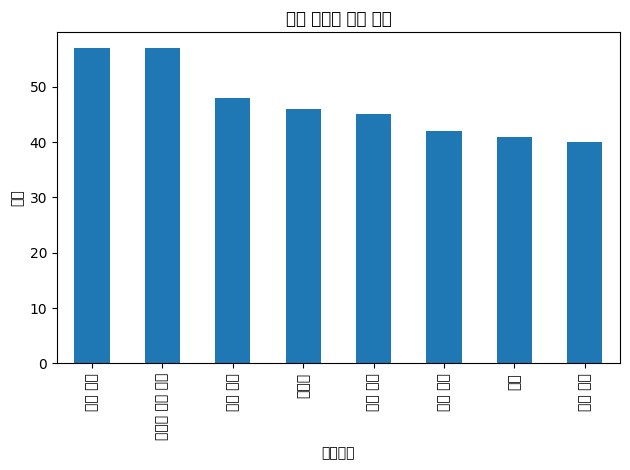

In [8]:
import matplotlib.pyplot as plt

defect_counts = df[df["불량유형"] != ""]["불량유형"].value_counts()
print(defect_counts)
defect_counts.plot(kind="bar")
plt.title("불량 유형별 발생 건수")
plt.ylabel("건수")
plt.tight_layout()
plt.show()

## 오류 대처 방법
- `groupby(...).sum()`에서 문자열 열까지 합치려다 오류가 나면, 숫자 열만 리스트로 지정했는지 확인.
- 빈 문자열(`""`)과 결측값(`NaN`)을 혼동하지 않도록 `df['불량유형'] != ""` 조건을 명확히 설명.

## 확장 실습(빠른 학습자용)
공정별 수율도 같은 방식으로 계산해 어떤 공정에서 불량이 상대적으로 많은지 확인해보게 한다.

In [9]:
by_process = df.groupby("공정명")[["양품수량", "검사수량"]].sum()
by_process["수율_pct"] = (by_process["양품수량"] / by_process["검사수량"] * 100).round(1)
by_process

,양품수량,검사수량,수율_pct
공정명,,,
산화,1746,1869,93.4
세정,1994,2128,93.7
식각,1590,1737,91.5
증착,985,1053,93.5
포토,2322,2667,87.1
